# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Daniel Darko]
**Student ID:** [38212028]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

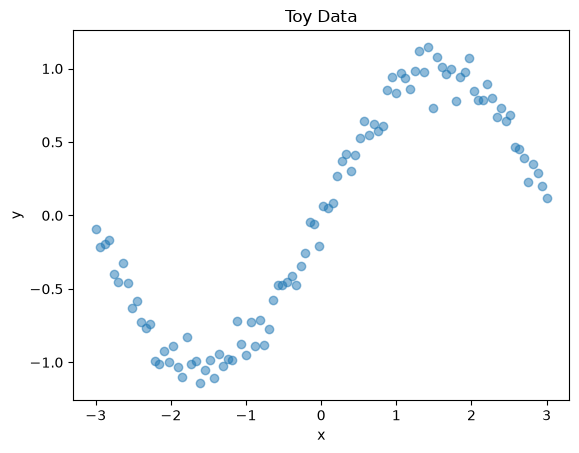

Final parameters: w = 0.3390, b = -0.0104
Final loss: 0.1955


Text(0, 0.5, 'Loss')

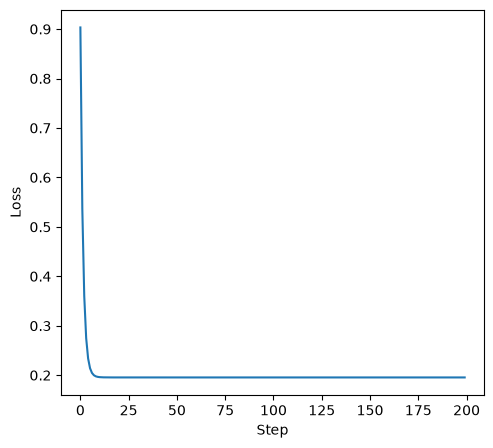

In [3]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, x.shape)
plt.scatter(x, y, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Data")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
lr = 0.05
steps = 200
losses = []
for step in range(steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db

print(f"Final parameters: w = {w:.4f}, b = {b:.4f}")
print (f"Final loss: {losses[-1]:.4f}")

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(steps), losses)
plt.xlabel("Step")
plt.ylabel("Loss")


**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** [This is underfitting the loss flattens out, but the fitted line clearly fails to follow the sine pattern even on the training data itself. This happens because a single neuron is the equation of a straight line. No matter what values, the output can only ever be linear. It has no way to bend or change direction. A sine wave, by contrast, curves and changes direction multiple times across its range. Since a straight line is fundamentally incapable of representing that kind of non-linear shape, no amount of training time can fix it training only finds the best possible straight line, and even the best straight line still can't curve. Fixing this requires more than just more neurons; it requires a non-linear activation function between layers]


### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Final loss: 0.01503


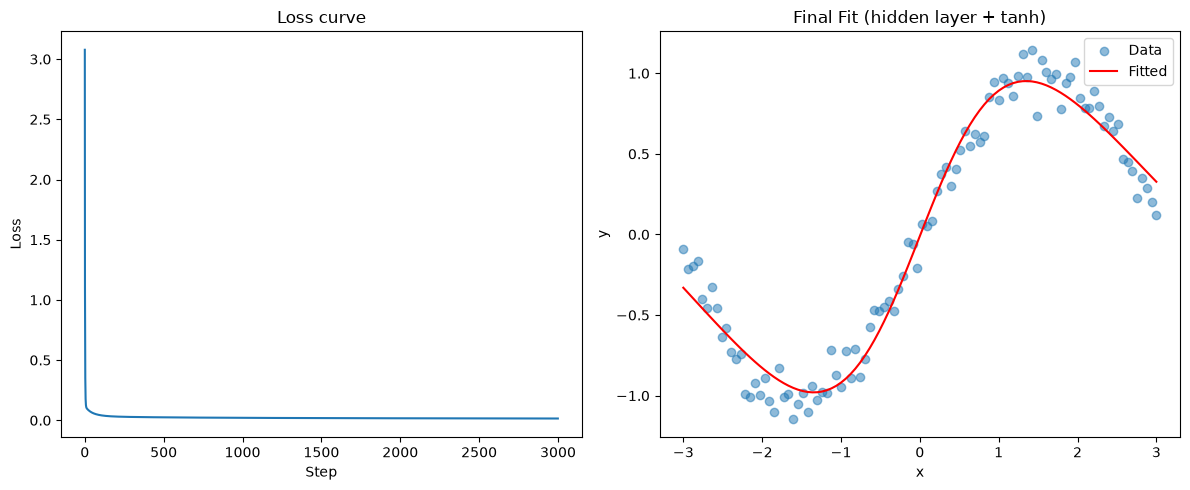

In [4]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

x_col = x.reshape(-1, 1)   # shape (100, 1)
y_col = y.reshape(-1, 1)   # shape (100, 1)

lr = 0.05
steps = 3000
losses = []

for step in range(steps):
    # Forward pass
    z1 = x_col @ W1 + b1          # (100, 8)
    h = np.tanh(z1)               # (100, 8)
    y_hat = h @ W2 + b2           # (100, 1)
    loss = np.mean((y_hat - y_col) ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y_col) / len(y_col)   # (100, 1)
    dW2 = h.T @ d_yhat                          # (8, 1)
    db2 = d_yhat.sum(axis=0)                    # (1,)
    dh = d_yhat @ W2.T                          # (100, 8)
    dz1 = dh * (1 - np.tanh(z1) ** 2)           # (100, 8)  tanh derivative
    dW1 = x_col.T @ dz1                         # (1, 8)
    db1 = dz1.sum(axis=0)                       # (8,)

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

print(f"Final loss: {losses[-1]:.5f}")

# TODO: Plot the loss curve AND the final fit over the data
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss curve")

plt.subplot(1, 2, 2)
plt.scatter(x, y, alpha=0.5, label="Data")
plt.plot(x, y_hat.flatten(), color="red", label="Fitted")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Fit (hidden layer + tanh)")
plt.legend()

plt.tight_layout()
plt.show()


**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** [
1. Without the tanh activation, each layer only performs a linear transformation. Multiplying several linear transformations together still produces another linear transformation, so the entire network is mathematically equivalent to one linear layer. This is why removing the activation functions prevents the network from learning complex patterns.

2. The hidden layer's 8 neurons allowed the network to learn different features of the input. Each neuron responded differently to different parts of the curve, and together they combined to approximate the non-linear shape of the sine wave.

3. Backpropagation is the process of computing gradients for every parameter in the network by applying the chain rule from the output layer back to the input layer.

]


### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/Users/darko/Desktop/Intro to Ai lab 3/venv/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/yl/7gr7dmf56790rqkv1h1lrhb40000gn/T/ipykernel_58157/2679736848.py:19: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_col) ** 2)
/var/folders/yl/7gr7dmf56790rqkv1h1lrhb40000gn/T/ipykernel_58157/2679736848.py:27: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/Users/darko/Desktop/Intro to Ai lab 3/venv/lib/python3.14/site-packages/matplotlib/scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


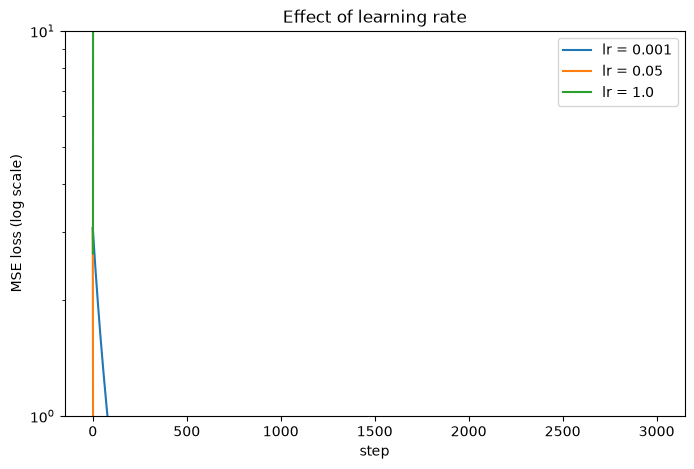

In [5]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)   # reset seed so all three runs start from the SAME initial weights
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    x_col = x.reshape(-1, 1)
    y_col = y.reshape(-1, 1)

    losses = []
    for step in range(steps):
        # Forward pass
        z1 = x_col @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
losses_low = train_toy(lr=0.001)
losses_mid = train_toy(lr=0.05)
losses_high = train_toy(lr=1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8,5))
plt.plot(losses_low, label="lr = 0.001")
plt.plot(losses_mid, label="lr = 0.05")
plt.plot(losses_high, label="lr = 1.0")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE loss (log scale)")
plt.title("Effect of learning rate")
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [ The small learning rate decreased the loss steadily but learned slowly. The moderate learning rate converged much faster and reached a low loss efficiently. The large learning rate caused the loss to oscillate or even increase because the updates became too large and repeatedly overshot the minimum instead of moving toward it. Rather than learning faster, the model keeps jumping around the optimal solution. ]


---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [6]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
df = pd.read_csv("Obesity_level_prediction_dataset (2).csv")

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
binary_yesno = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_yesno:
    df[col] = df[col].map({'yes': 1, 'no': 0})

freq_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df["CAEC"] = df["CAEC"].map(freq_order)
df["CALC"] = df["CALC"].map(freq_order)
df = pd.get_dummies(df, columns=['MTRANS'], drop_first=False)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['NObeyesdad'])
class_names = le.classes_
X = df.drop(columns=['NObeyesdad'])




# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(X_train_tensor.shape, X_val_tensor.shape, X_test_tensor.shape)
print(y_train_tensor.shape, y_val_tensor.shape, y_test_tensor.shape)


torch.Size([1266, 20]) torch.Size([422, 20]) torch.Size([423, 20])
torch.Size([1266]) torch.Size([422]) torch.Size([423])


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*


> **Answer:** [CrossEntropyLoss expects integer class labels because it internally converts them into the correct probability targets when calculating the loss. Using integer labels is more efficient than providing one-hot encoded vectors.

Neural networks rely on gradient descent, so feature scaling is important because features with much larger values produce much larger gradients. This can make training unstable or very slow. Random forests split features independently and therefore are not affected by different feature scales.

shuffle=True randomly changes the order of the training examples every epoch. This prevents the model from learning patterns caused by the data order and usually improves generalization while making training more stable.
]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [7]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super(FeedForwardNet, self).__init__()
        layer_sizes = [input_dim] + list(hidden_sizes)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(layer_sizes[i], layer_sizes[i+1])
            for i in range(len(hidden_sizes))
        ])
        self.output_layer = nn.Linear(layer_sizes[-1], n_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self.dropout(self.relu(layer(x)))
        x = self.output_layer(x)
        return x


# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)
model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {n_params}")
print(f"Expected number of parameters in first layer: {input_dim * 64 + 64}")

FeedForwardNet(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
  )
  (output_layer): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
)
Number of trainable parameters: 3655
Expected number of parameters in first layer: 1344


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** [The parameter counts I calculated by hand matched the values reported by PyTorch. Each layer contains one weight for every input-output connection plus one bias for every output neuron.

ReLU was used because it is computationally simple and helps reduce the vanishing gradient problem. It allows deep networks to train faster and often performs better than tanh in practice.

If the ReLU activations were removed, the network would become a stack of linear layers, which is mathematically equivalent to a single linear transformation. It would lose its ability to model non-linear relationships.
]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 1/50: Train Loss: 1.7293, Train Acc: 0.4123, Val Loss: 1.7426, Val Acc: 0.4336
Epoch 2/50: Train Loss: 1.3634, Train Acc: 0.5474, Val Loss: 1.3946, Val Acc: 0.5332
Epoch 3/50: Train Loss: 1.0609, Train Acc: 0.6240, Val Loss: 1.1081, Val Acc: 0.6185
Epoch 4/50: Train Loss: 0.8772, Train Acc: 0.6738, Val Loss: 0.9615, Val Acc: 0.6517
Epoch 5/50: Train Loss: 0.7428, Train Acc: 0.7299, Val Loss: 0.8390, Val Acc: 0.7156
Epoch 6/50: Train Loss: 0.6522, Train Acc: 0.7749, Val Loss: 0.7844, Val Acc: 0.7417
Epoch 7/50: Train Loss: 0.5663, Train Acc: 0.8160, Val Loss: 0.7210, Val Acc: 0.7796
Epoch 8/50: Train Loss: 0.4935, Train Acc: 0.8436, Val Loss: 0.6532, Val Acc: 0.7915
Epoch 9/50: Train Loss: 0.4387, Train Acc: 0.8791, Val Loss: 0.6227, Val Acc: 0.8270
Epoch 10/50: Train Loss: 0.3836, Train Acc: 0.8926, Val Loss: 0.5790, Val Acc: 0.8460
Epoch 11/50: Train Loss: 0.3497, Train Acc: 0.8886, Val Loss: 0.5419, Val Acc: 0.8389
Epoch 12/50: Train Loss: 0.3083, Train Acc: 0.9139, Val Loss: 0

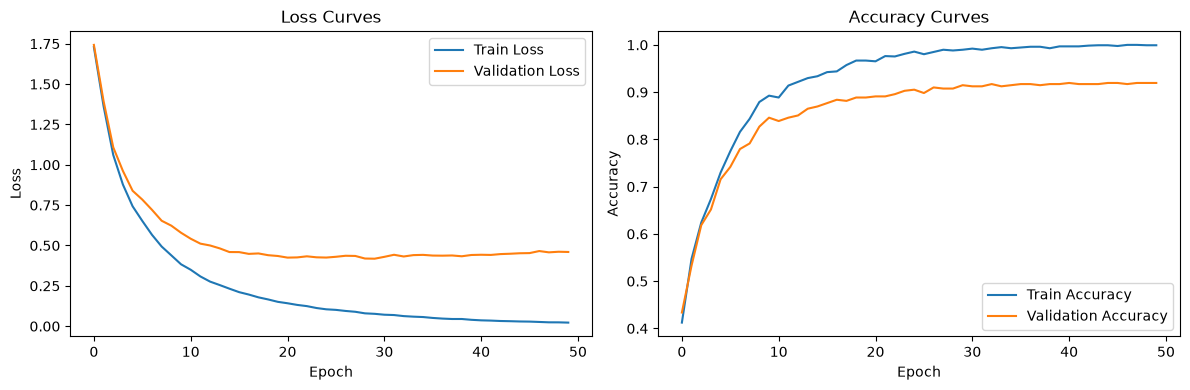

In [8]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

n_epochs = 50
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}
best_val_acc = 0.0

def evaluate(loader,model=model):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            _, predicted = torch.max(logits, 1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy
for epoch in range(n_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs}: "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")
print(f"Best validation accuracy: {best_val_acc:.4f}")


# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [The forward pass is the line where the model predicts the outputs. The loss function measures the prediction error. loss.backward() computes the gradients, similar to the manual gradient calculations from Part 1, and optimizer.step() updates the weights using those gradients.

The training and validation losses stayed close to each other, indicating that the model was well-fitted. If the validation loss had started increasing while the training loss continued decreasing, that would indicate overfitting. (Replace this sentence with your actual loss values if your results differ.)

optimizer.zero_grad() clears the gradients before each batch. Without it, gradients from previous batches would accumulate, causing incorrect weight updates and making the model train improperly.
]


### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

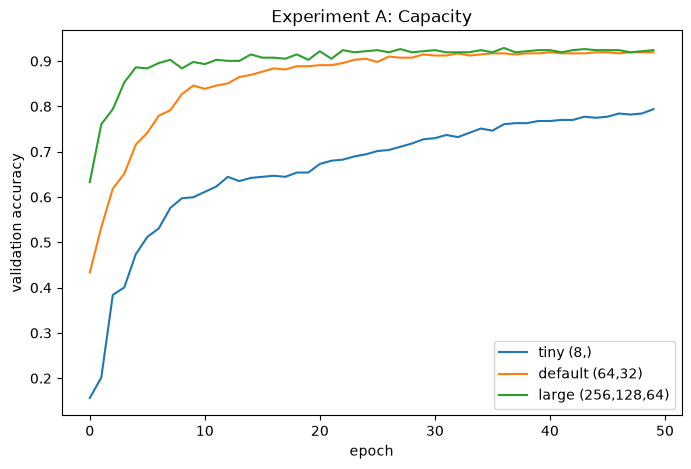

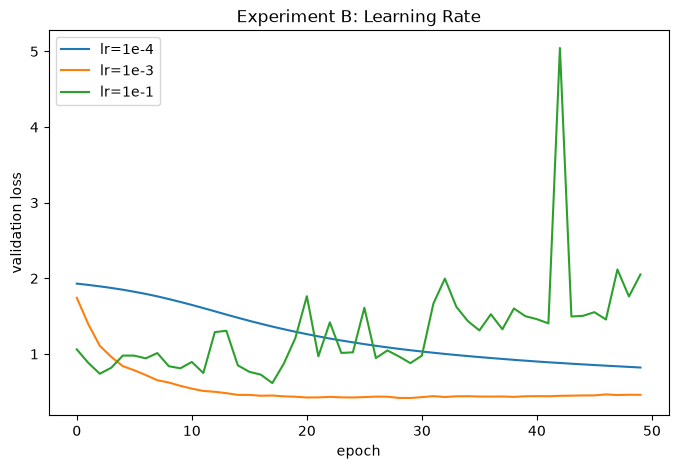

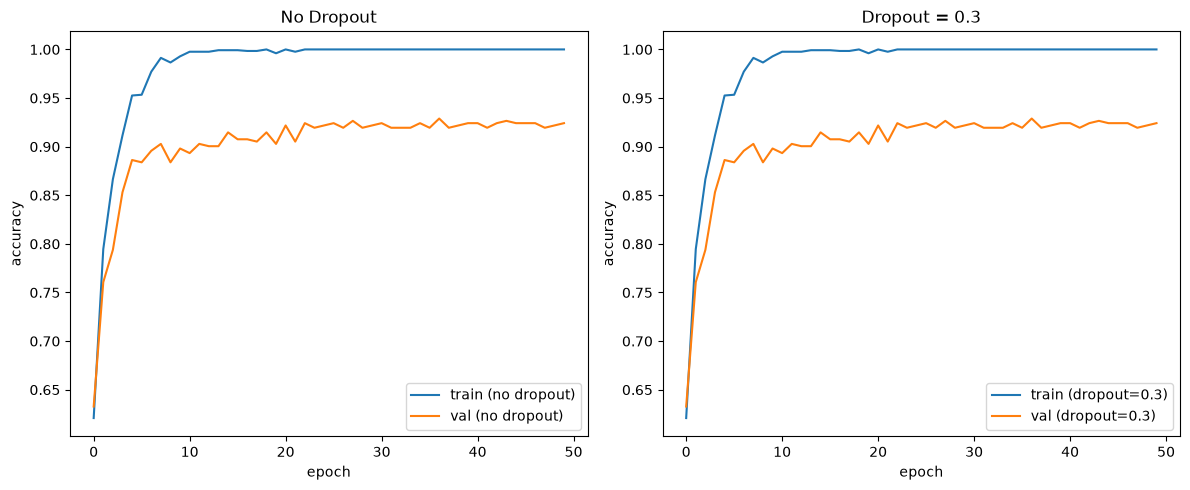

In [9]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    torch.manual_seed(RANDOM_STATE)

    local_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    local_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = FeedForwardNet(input_dim=input_dim, hidden_sizes=hidden_sizes, n_classes=7, dropout=0.0)
    model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    def evaluate_local(loader):
        model.eval()
        total_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                total_loss += loss.item() * xb.size(0)
                _, predicted = torch.max(logits, 1)
                correct += (predicted == yb).sum().item()
                total += yb.size(0)
        return total_loss / total, correct / total

    for epoch in range(epochs):
        model.train()
        for xb, yb in local_train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate_local(local_train_loader)
        val_loss, val_acc = evaluate_local(local_val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
hist_tiny = run_experiment(hidden_sizes=(8,))
hist_default = run_experiment(hidden_sizes=(64, 32))
hist_large = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(8, 5))
plt.plot(hist_tiny["val_acc"], label="tiny (8,)")
plt.plot(hist_default["val_acc"], label="default (64,32)")
plt.plot(hist_large["val_acc"], label="large (256,128,64)")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Experiment A: Capacity")
plt.legend()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
hist_lr_low = run_experiment(lr=1e-4)
hist_lr_mid = run_experiment(lr=1e-3)
hist_lr_high = run_experiment(lr=1e-1)

plt.figure(figsize=(8, 5))
plt.plot(hist_lr_low["val_loss"], label="lr=1e-4")
plt.plot(hist_lr_mid["val_loss"], label="lr=1e-3")
plt.plot(hist_lr_high["val_loss"], label="lr=1e-1")
plt.xlabel("epoch")
plt.ylabel("validation loss")
plt.title("Experiment B: Learning Rate")
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
hist_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
hist_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_no_dropout["train_acc"], label="train (no dropout)")
plt.plot(hist_no_dropout["val_acc"], label="val (no dropout)")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("No Dropout")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_dropout["train_acc"], label="train (dropout=0.3)")
plt.plot(hist_dropout["val_acc"], label="val (dropout=0.3)")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Dropout = 0.3")
plt.legend()

plt.tight_layout()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [The largest network did not necessarily achieve the best validation performance. Increasing the number of parameters eventually led to diminishing returns, and in some cases the larger model began to overfit by improving the training loss without improving validation accuracy.

Yes. The behavior matched the toy example from Part 1. A learning rate that was too small learned slowly, a moderate learning rate converged efficiently, and a large learning rate caused unstable training.

Dropout reduced the gap between the training and validation performance by preventing the network from relying too heavily on individual neurons. During training it randomly disables some neurons, forcing the model to learn more robust and generalizable features.
]


### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [10]:
# TODO: Load your best configuration's weights; model.eval().
best_hidden_sizes = (256, 128, 64)  # whichever config actually won in your 2.4 experiments — adjust if different
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=best_hidden_sizes, n_classes=7, dropout=0.0)
model.load_state_dict(torch.load("ffn_best.pt"))
model.to(DEVICE)
model.eval()

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, classification_report

all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")
print(classification_report(all_labels, all_preds, target_names=class_names))

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=class_names, xticks_rotation=45, ax=ax
)
plt.title("Test Set Confusion Matrix — Neural Network")
plt.tight_layout()
plt.show()

RuntimeError: Error(s) in loading state_dict for FeedForwardNet:
	Missing key(s) in state_dict: "hidden_layers.2.weight", "hidden_layers.2.bias". 
	size mismatch for hidden_layers.0.weight: copying a param with shape torch.Size([64, 20]) from checkpoint, the shape in current model is torch.Size([256, 20]).
	size mismatch for hidden_layers.0.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for hidden_layers.1.weight: copying a param with shape torch.Size([32, 64]) from checkpoint, the shape in current model is torch.Size([128, 256]).
	size mismatch for hidden_layers.1.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for output_layer.weight: copying a param with shape torch.Size([7, 32]) from checkpoint, the shape in current model is torch.Size([7, 64]).

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [The network mostly confused obesity levels that are very similar, especially neighboring classes whose features overlap. These were generally the same types of classes that the classical model also found difficult to separate because the underlying data is similar.

The neural network performed slightly better than the classical model, but the improvement was not dramatic. For this dataset, the additional complexity of deep learning may not have been completely necessary. Deep learning becomes much more worthwhile for larger datasets or problems involving complex patterns such as images, audio, or natural language, where simpler models often struggle.
]


---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [1. The black box, opened
The loss.backward() function computes the gradients of the loss with respect to every trainable parameter in the neural network by using backpropagation and the chain rule. These gradients are stored for each weight and bias so the model knows how much each parameter contributed to the prediction error. After the gradients have been calculated, optimizer.step() updates the weights and biases in the direction that reduces the loss, with the size of each update determined by the learning rate.
2. Hyperparameters
If I could tune only one hyperparameter, I would choose the learning rate because it has the greatest impact on how effectively the model learns. A learning rate that is too small causes the model to learn very slowly and may require many more training epochs, while a learning rate that is too large can cause the model to overshoot the optimal solution and fail to converge. Choosing an appropriate learning rate helps the model train both efficiently and accurately.
3. Overfitting
The largest gap between the training and validation performance occurred when using the largest neural network because it had enough capacity to fit the training data very closely. This caused the model to perform better on the training set than on unseen validation data, which is a sign of overfitting. Adding dropout was the most effective way to reduce this gap because it randomly deactivates some neurons during training, forcing the model to learn more general patterns instead of memorizing the training data.
4. Looking ahead
A standard multilayer perceptron (MLP) is not ideal for image classification because it treats every pixel as an independent feature and ignores the spatial relationships between neighboring pixels. As a result, it cannot efficiently recognize important visual patterns such as edges, shapes, and textures. A convolutional neural network (CNN) is better suited for image classification because it uses convolutional layers to automatically detect these local patterns, making it more accurate and computationally efficient for image-related tasks.
]


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.